# f(x) = x * sin(5x)

In [1]:
import deepxde as dde
import numpy as np

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
def func(x):
    """
    x: array_like N x D_in
    y: array_like N x D_out
    """
    
    return x * np.sin(5 * x)

In [3]:
geom = dde.geometry.Interval(-1, 1)

Here, we use 16 points for training sampled inside the domain, and 100 points for testing.

In [4]:
num_train = 16
num_test = 100
data = dde.data.Function(geom, func, num_train, num_test)

In [5]:
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN([1] + [20] * 3 + [1], activation, initializer)

In [8]:
model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])

Compiling model...
'compile' took 0.000236 s



In [10]:
losshistory, train_state = model.train(iterations=10000)

Training model...

Step      Train loss    Test loss     Test metric   
0         [2.82e-01]    [2.42e-01]    [1.08e+00]    
1000      [4.61e-04]    [4.28e-04]    [4.53e-02]    
2000      [3.51e-05]    [7.94e-05]    [1.95e-02]    
3000      [1.23e-05]    [4.89e-05]    [1.53e-02]    
4000      [7.41e-06]    [4.33e-05]    [1.44e-02]    
5000      [5.13e-06]    [4.03e-05]    [1.39e-02]    
6000      [3.08e-05]    [5.91e-05]    [1.68e-02]    
7000      [1.45e-05]    [4.72e-05]    [1.50e-02]    
8000      [2.31e-06]    [3.23e-05]    [1.24e-02]    
9000      [1.74e-06]    [2.93e-05]    [1.19e-02]    
10000     [1.29e-06]    [2.66e-05]    [1.13e-02]    

Best model at step 10000:
  train loss: 1.29e-06
  test loss: 2.66e-05
  test metric: [1.13e-02]

'train' took 11.267740 s



Saving loss history to /home/hridoy/Softwares/GitHubRepos/Python/PyTorch/DeepXDE/Function_approximation/loss.dat ...
Saving training data to /home/hridoy/Softwares/GitHubRepos/Python/PyTorch/DeepXDE/Function_approximation/train.dat ...
Saving test data to /home/hridoy/Softwares/GitHubRepos/Python/PyTorch/DeepXDE/Function_approximation/test.dat ...


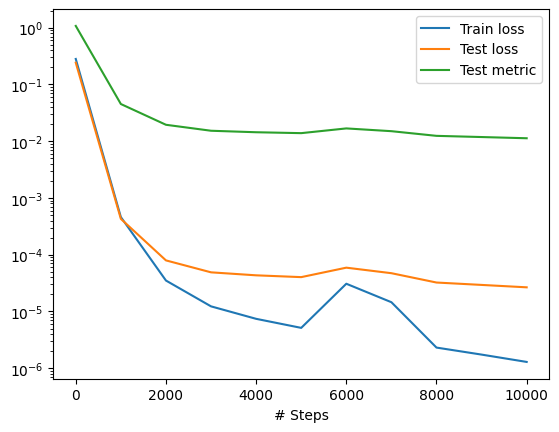

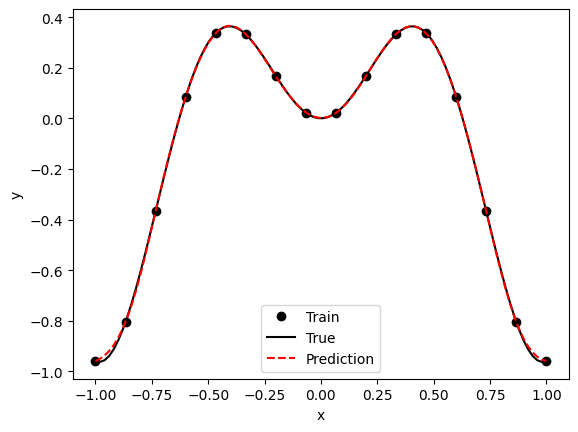

In [12]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)